<a href="https://colab.research.google.com/github/kiranj0435-gif/kiranj0435-gif/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
data1 = pd.read_csv("/content/Finance_1.csv")
data2 = pd.read_excel("/content/Finance_2.xlsx")

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
df1

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,verification_status,issue_d,loan_status,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti
0,54734,80364,25000,25000,19080.057200,36 months,11.89%,829.10,B,B4,...,Verified,Aug-09,Fully Paid,n,Due to a lack of personal finance education an...,debt_consolidation,Debt consolidation for on-time payer,941xx,CA,19.48
1,55742,114426,7000,7000,672.803839,36 months,10.71%,228.22,B,B5,...,Not Verified,May-08,Fully Paid,n,Just want to pay off the last bit of credit ca...,credit_card,Credit Card payoff,112xx,NY,14.29
2,57245,138150,1200,1200,1200.000000,36 months,13.11%,40.50,C,C2,...,Not Verified,Mar-10,Fully Paid,n,"If funded, I would use this loan consolidate t...",debt_consolidation,zxcvb,777xx,TX,5.47
3,57416,139635,10800,10800,10691.551050,36 months,13.57%,366.86,C,C3,...,Not Verified,Nov-09,Fully Paid,n,I currently have a personal loan with Citifina...,debt_consolidation,Nicolechr1978,067xx,CT,11.63
4,58915,153417,7500,5025,557.087228,36 months,10.08%,162.34,B,B3,...,Not Verified,Apr-08,Fully Paid,n,Hi : Thanks for stopping by. I've accr...,debt_consolidation,sdguy,921xx,CA,8.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,1075358,1311748,3000,3000,3000.000000,60 months,12.69%,67.79,B,B5,...,Source Verified,Dec-11,Current,n,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94
39713,1076863,1277178,10000,10000,10000.000000,36 months,13.49%,339.31,C,C1,...,Source Verified,Dec-11,Fully Paid,n,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00
39714,1077175,1313524,2400,2400,2400.000000,36 months,15.96%,84.33,C,C5,...,Not Verified,Dec-11,Fully Paid,n,NaN,small_business,real estate business,606xx,IL,8.72
39715,1077430,1314167,2500,2500,2500.000000,60 months,15.27%,59.83,C,C4,...,Source Verified,Dec-11,Charged Off,n,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00


In [24]:
df1.head()
df2.head()
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   39717 non-null  int64  
 1   member_id            39717 non-null  int64  
 2   loan_amnt            39717 non-null  int64  
 3   funded_amnt          39717 non-null  int64  
 4   funded_amnt_inv      39717 non-null  float64
 5   term                 39717 non-null  object 
 6   int_rate             39717 non-null  object 
 7   installment          39717 non-null  float64
 8   grade                39717 non-null  object 
 9   sub_grade            39717 non-null  object 
 10  emp_title            37258 non-null  object 
 11  emp_length           38642 non-null  object 
 12  home_ownership       39717 non-null  object 
 13  annual_inc           39717 non-null  float64
 14  verification_status  39717 non-null  object 
 15  issue_d              39717 non-null 

In [25]:
df1["issue_d"] = pd.to_datetime(df1["issue_d"], errors='coerce')
df2["last_pymnt_d"] = pd.to_datetime(df2["last_pymnt_d"], errors='coerce')

/tmp/ipykernel_9958/2591050171.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1["issue_d"] = pd.to_datetime(df1["issue_d"], errors='coerce')


In [31]:
df1.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0


In [29]:
df = pd.merge(df1, df2, on="id")

In [30]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       39717 non-null  int64         
 1   member_id                39717 non-null  int64         
 2   loan_amnt                39717 non-null  int64         
 3   funded_amnt              39717 non-null  int64         
 4   funded_amnt_inv          39717 non-null  float64       
 5   term                     39717 non-null  object        
 6   int_rate                 39717 non-null  object        
 7   installment              39717 non-null  float64       
 8   grade                    39717 non-null  object        
 9   sub_grade                39717 non-null  object        
 10  emp_title                37258 non-null  object        
 11  emp_length               38642 non-null  object        
 12  home_ownership           39717 n

In [42]:
#kpi 1 total loan by year
df["year"] = df["issue_d"].dt.year
total_loan = df.groupby("year")["loan_amnt"].sum()
total_loan

,loan_amnt
year,
2007,2219275
2008,14390275
2009,46436325
2010,122050200
2011,260506575


In [46]:
df["month"] = df["issue_d"].dt.month
monthly_loan = df.groupby("month")["loan_amnt"].sum()
monthly_loan

,loan_amnt
month,
1,25351575
2,25390450
3,29488775
4,30413600
5,32528975
6,34862625
7,36637975
8,38888925
9,41906775


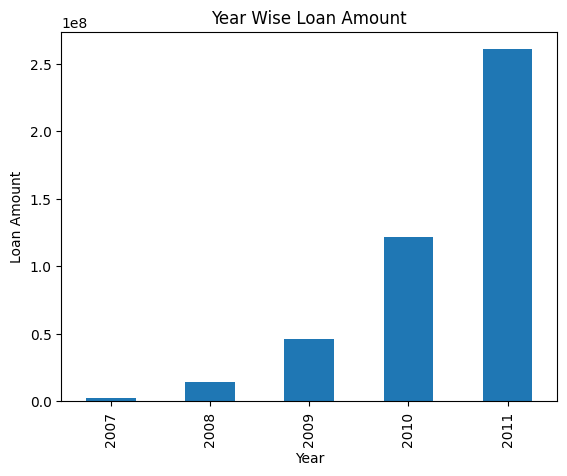

In [54]:
#year wise bar chart
import matplotlib.pyplot as plt

total_loan.plot(kind = "bar")
plt.title("Year Wise Loan Amount")
plt.xlabel("Year")
plt.ylabel("Loan Amount")
plt.show()

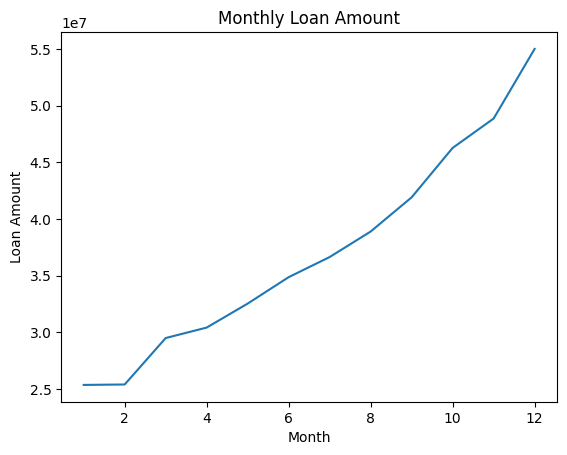

In [56]:
#Month-wise Line Chart
monthly_loan.plot(kind = "line")
plt.title("Monthly Loan Amount")
plt.xlabel("Month")
plt.ylabel("Loan Amount")
plt.show()


In [57]:
#kpi2  : Grade & Sub-grade vs Revolving Balance

grage_revol = df.groupby(["grade", "sub_grade"])["revol_bal"].sum()
grage_revol

grade  sub_grade
A      A1           11365196
       A2           14004780
       A3           19543922
       A4           34557156
       A5           35303045
B      B1           21842079
       B2           26478439
       B3           39723554
       B4           35405811
       B5           37858666
C      C1           29384926
       C2           27321114
       C3           20531370
       C4           16867691
       C5           16015609
D      D1           12130255
       D2           18570972
       D3           16793781
       D4           13742947
       D5           13252474
E      E1           11132588
       E2           10242033
       E3            9039059
       E4            7990991
       E5            7669868
F      F1            5840746
       F2            4528248
       F3            3175435
       F4            2551064
       F5            2187323
G      G1            1808763
       G2            1729627
       G3             832193
       G4            1390628
       G5             701515
Name: revol_bal, dtype: int64

In [61]:
pivot_data = df.pivot_table(
    values="revol_bal",
    index="grade",
    columns="sub_grade",
    aggfunc="sum"
)
pivot_data.head()

sub_grade,A1,A2,A3,A4,A5,B1,B2,B3,B4,B5,...,F1,F2,F3,F4,F5,G1,G2,G3,G4,G5
grade,,,,,,,,,,,,,,,,,,,,,
A,11365196.0,14004780.0,19543922.0,34557156.0,35303045.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,NaN,NaN,NaN,NaN,NaN,21842079.0,26478439.0,39723554.0,35405811.0,37858666.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


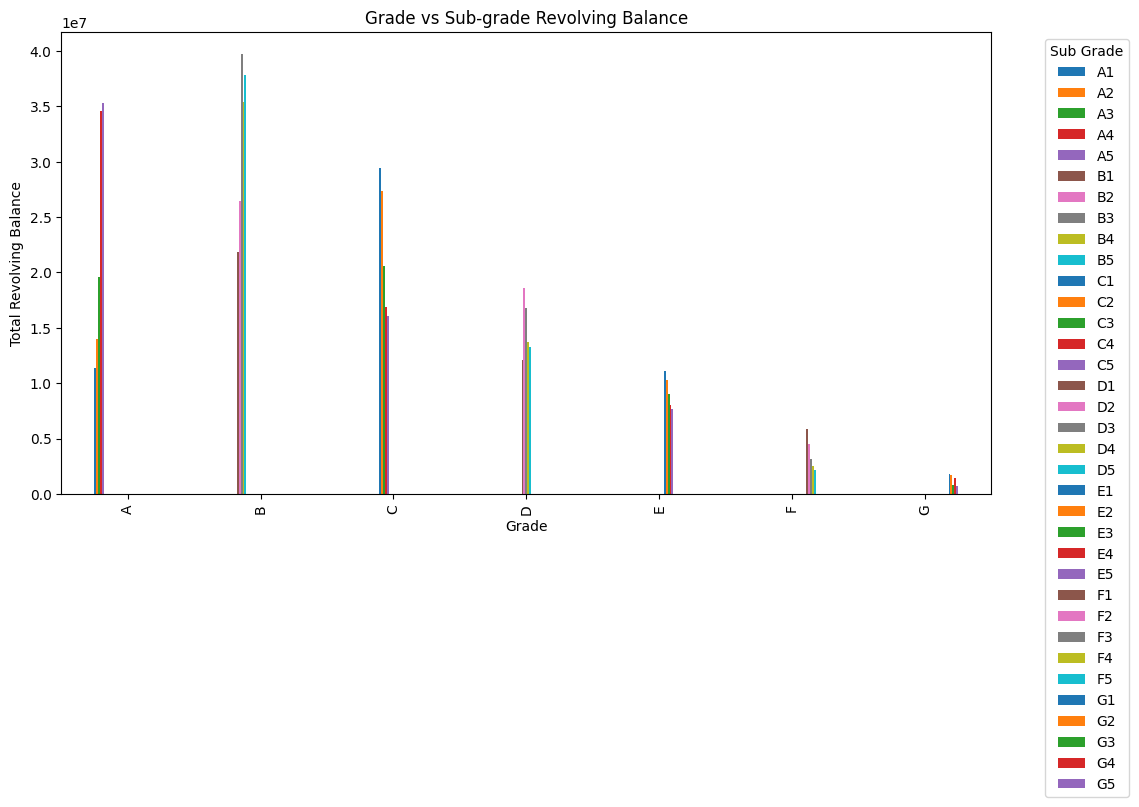

In [63]:
pivot_data.plot(kind="bar", figsize=(12,6))

plt.title("Grade vs Sub-grade Revolving Balance")
plt.xlabel("Grade")
plt.ylabel("Total Revolving Balance")

plt.legend(title="Sub Grade", bbox_to_anchor=(1.05, 1))
plt.show()

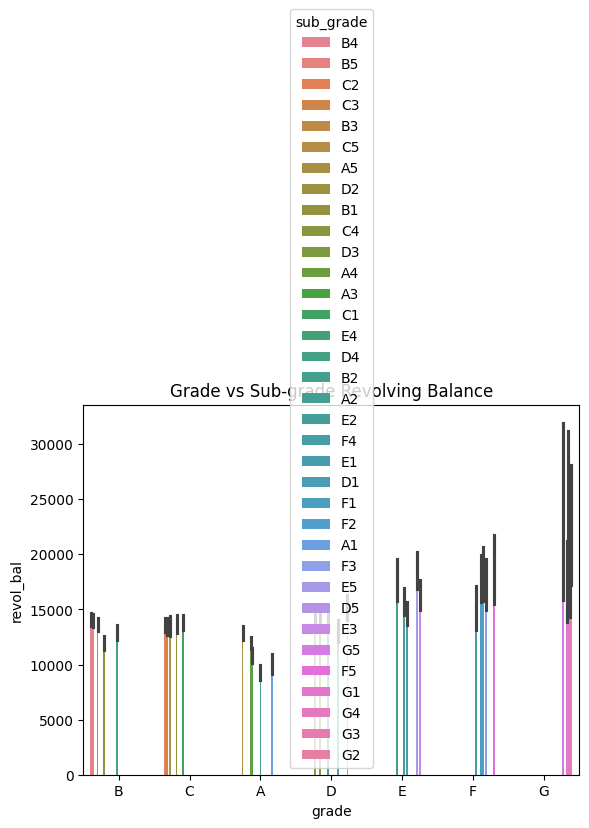

In [64]:
import seaborn as sns


sns.barplot(data=df, x="grade", y="revol_bal", hue="sub_grade")

plt.title("Grade vs Sub-grade Revolving Balance")
plt.show()

In [67]:
#kpi3 Verified vs Non-Verified Total Payment
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       39717 non-null  int64         
 1   member_id                39717 non-null  int64         
 2   loan_amnt                39717 non-null  int64         
 3   funded_amnt              39717 non-null  int64         
 4   funded_amnt_inv          39717 non-null  float64       
 5   term                     39717 non-null  object        
 6   int_rate                 39717 non-null  object        
 7   installment              39717 non-null  float64       
 8   grade                    39717 non-null  object        
 9   sub_grade                39717 non-null  object        
 10  emp_title                37258 non-null  object        
 11  emp_length               38642 non-null  object        
 12  home_ownership           39717 n

In [69]:
total_verified = df.groupby("verification_status")["total_pymnt"].sum()
total_verified

,total_pymnt
verification_status,
Not Verified,1.535414e+08
Source Verified,1.092707e+08
Verified,2.198923e+08


<Axes: xlabel='verification_status'>

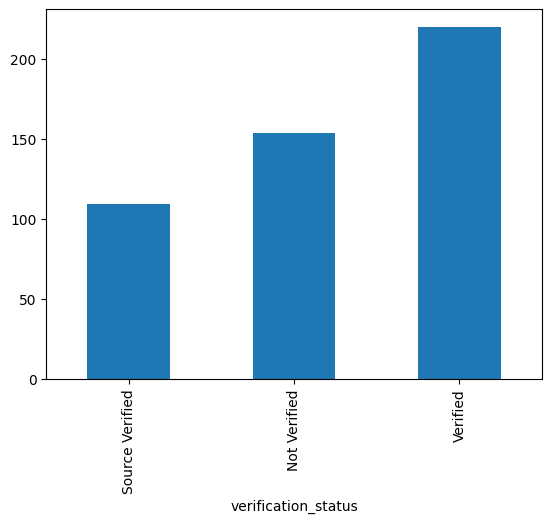

In [72]:

total_verified = total_verified.sort_values()
total_verified_m = total_verified / 1000000
total_verified_m.plot(kind = "bar")


In [73]:
#KPI 4: State-wise & Month-wise Loan Status

In [81]:
state_status = df.groupby(["addr_state", "loan_status"]).size().unstack()
print(state_status.head())

loan_status  Charged Off  Current  Fully Paid
addr_state                                   
AK                  15.0      2.0        63.0
AL                  54.0     17.0       381.0
AR                  27.0     10.0       208.0
AZ                 123.0     30.0       726.0
CA                1125.0    150.0      5824.0


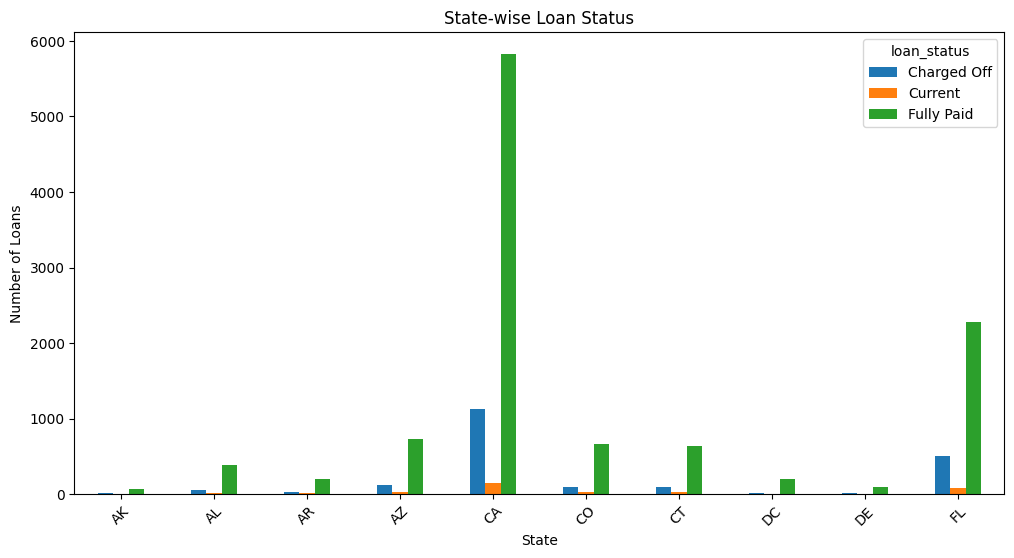

In [83]:
state_status.head(10).plot(kind="bar", figsize=(12,6))

plt.title("State-wise Loan Status")
plt.xlabel("State")
plt.ylabel("Number of Loans")

plt.xticks(rotation=45)
plt.show()

In [82]:
month_status = df.groupby(["month", "loan_status"]).size().unstack()
print(month_status)

loan_status  Charged Off  Current  Fully Paid
month                                        
1                  321.0      NaN      2058.0
2                  290.0      NaN      2068.0
3                  347.0      1.0      2344.0
4                  370.0      3.0      2461.0
5                  466.0     80.0      2453.0
6                  483.0     99.0      2697.0
7                  479.0    125.0      2872.0
8                  468.0    130.0      2920.0
9                  547.0    150.0      2951.0
10                 580.0    173.0      3181.0
11                 598.0    161.0      3408.0
12                 678.0    218.0      3537.0


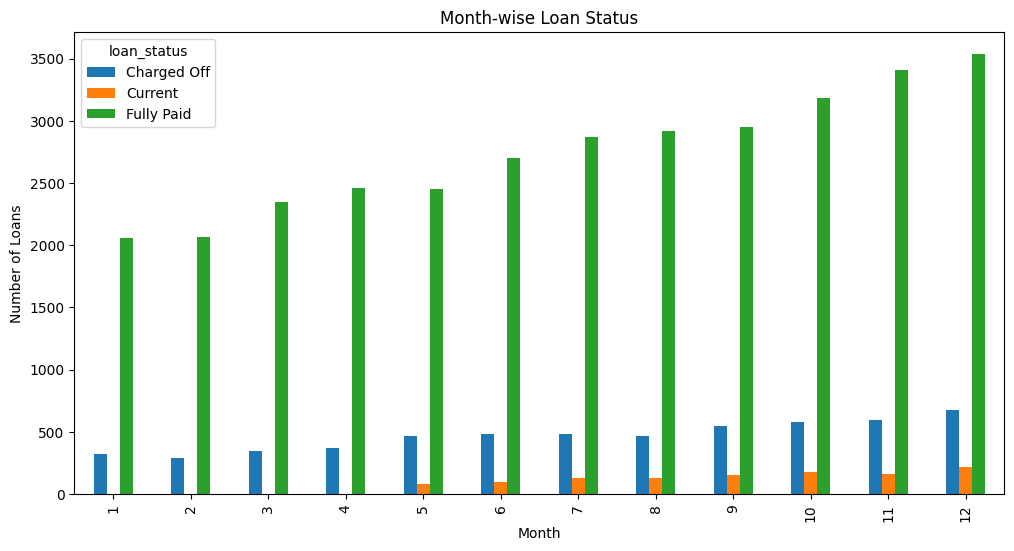

In [84]:
month_status.plot(kind="bar", figsize=(12,6))

plt.title("Month-wise Loan Status")
plt.xlabel("Month")
plt.ylabel("Number of Loans")

plt.xticks(range(0,12), range(1,13))
plt.show()

In [87]:
ho_pd = df.groupby(["home_ownership","last_pymnt_d"]).size().unstack()
print(ho_pd)

last_pymnt_d    2008-01-01  2008-02-01  2008-03-01  2008-04-01  2008-05-01  \
home_ownership                                                               
MORTGAGE               3.0         NaN         2.0         5.0         9.0   
NONE                   NaN         NaN         NaN         NaN         NaN   
OTHER                  NaN         NaN         NaN         NaN         NaN   
OWN                    1.0         NaN         1.0         3.0         1.0   
RENT                   NaN         1.0         2.0         4.0         4.0   

last_pymnt_d    2008-06-01  2008-07-01  2008-08-01  2008-09-01  2008-10-01  \
home_ownership                                                               
MORTGAGE               4.0         7.0         3.0         2.0        10.0   
NONE                   NaN         NaN         NaN         NaN         NaN   
OTHER                  NaN         NaN         NaN         NaN         NaN   
OWN                    1.0         NaN         1.0         NaN 

In [90]:
df["last_pymnt_year"] = df["last_pymnt_d"].dt.year
df["last_pymnt_month"] = df["last_pymnt_d"].dt.month

In [92]:
hoy = df.groupby(["home_ownership","last_pymnt_year"]).size().unstack()
hoy

last_pymnt_year,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0
home_ownership,,,,,,,,,
MORTGAGE,56.0,229.0,706.0,2131.0,3786.0,4254.0,4172.0,1207.0,1104.0
NONE,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN
OTHER,NaN,12.0,16.0,34.0,35.0,NaN,NaN,1.0,NaN
OWN,11.0,39.0,185.0,422.0,700.0,703.0,673.0,160.0,160.0
RENT,70.0,279.0,939.0,2408.0,4383.0,4501.0,4424.0,1063.0,780.0


In [94]:
hom = df.groupby(["home_ownership","last_pymnt_month"]).size().unstack()
hom

last_pymnt_month,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
home_ownership,,,,,,,,,,,,
MORTGAGE,1295.0,1404.0,1636.0,1414.0,2073.0,1292.0,1461.0,1457.0,1386.0,1460.0,1313.0,1454.0
NONE,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
OTHER,1.0,10.0,14.0,9.0,11.0,8.0,9.0,7.0,8.0,7.0,8.0,6.0
OWN,244.0,277.0,276.0,232.0,311.0,221.0,247.0,245.0,205.0,268.0,248.0,279.0
RENT,1501.0,1519.0,1835.0,1549.0,1890.0,1412.0,1509.0,1533.0,1414.0,1536.0,1376.0,1773.0


Text(0, 0.5, 'Number of Loans')

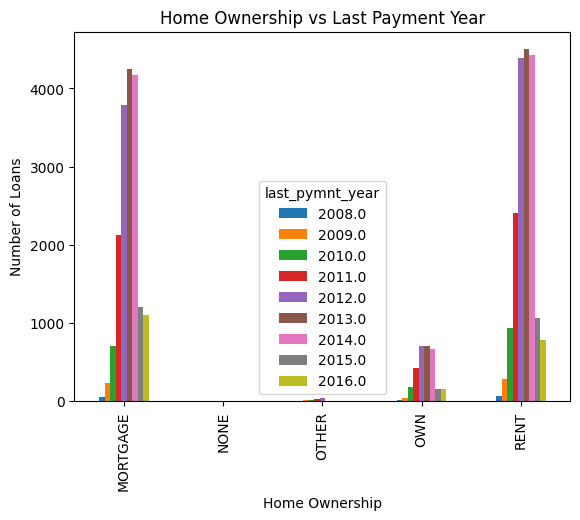

In [98]:
hoy.plot(kind = "bar")
plt.title("Home Ownership vs Last Payment Year")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Loans")